# Answers for week 7
* Name: Matthias van Weeren
* Username: mbweeren
* Student snumber: s6457002
* Group: AS2

### Q7.1 (session quiz)

In [1]:
import numpy as np
from numpy import linalg as la

A = np.array([[1,2,3],[0,-4,1],[0,3,-1]]).reshape(3,3)

det = la.det(A)
print(f"Determinant of M is: {det:.6f}")

B = np.array([2,2,-1])
X = la.solve(A, B)
x, y, z = X
print(f"\nSolution x, y, z={x:.6f}, {y:.6f}, {z:.6f}")
print()

Atrans = A.T
C = A@Atrans
print(f"A dot Atrans = \n{C}")
if np.array_equal(C, np.identity(3)):
    print("Since  A dot Atrans = I, A is orthogonal.")
else:
    print("A is not orthogonal.")
    
Lambda, v = la.eig(A)
print()
print("The eigenvalues of A are: Lambda = ", Lambda)

Determinant of M is: 1.000000

Solution x, y, z=10.000000, -1.000000, -2.000000

A dot Atrans = 
[[ 14  -5   3]
 [ -5  17 -13]
 [  3 -13  10]]
A is not orthogonal.

The eigenvalues of A are: Lambda =  [ 1.         -4.79128785 -0.20871215]


### Q7.2

### Q7.3 (session quiz)

In [2]:
import numpy as np
from numpy import linalg as la, cos, sin, radians

beta = radians(90 - 27.4)
gamma1 = radians(180 - 123)
gamma2 = radians(192.25)

E_y = np.array([[cos(beta), 0, -sin(beta)], [0, 1, 0], [sin(beta), 0, cos(beta)]]).reshape(3,3)
E_z1 = np.array([[cos(gamma1), sin(gamma1), 0], [-sin(gamma1), cos(gamma1), 0], [0, 0, 1]]).reshape(3,3)
E_z2 = np.array([[cos(gamma2), sin(gamma2), 0], [-sin(gamma2), cos(gamma2), 0], [0, 0, 1]]).reshape(3,3)

E = E_z1@E_y@E_z2
print(f"E = \n{E}")
print()

print(f"E*E.T = \n {np.round(E@E.T, decimals=3)} \n This is indeed the identity matrix, proving that the composed matrix is a rotation matrix.")
print()

Lambda, v = la.eig(E)
print(f"Eigenvalues are lambda = {Lambda}")
print()

E = 
[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]

E*E.T = 
 [[ 1. -0. -0.]
 [-0.  1.  0.]
 [-0.  0.  1.]] 
 This is indeed the identity matrix, proving that the composed matrix is a rotation matrix.

Eigenvalues are lambda = [-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]



In [3]:
from numpy.linalg import norm
alfa = radians(192.25)
delta = radians(27.4)

r = np.array([cos(delta)*cos(alfa), cos(delta)*sin(alfa), sin(delta)])
v = r/norm(r)

print(f"v = {v} and the norm of v is {norm(v):.1f}.")

v = [-0.86760081 -0.1883746   0.46019978] and the norm of v is 1.0.


In [4]:
print(f"v2 = {np.round(E@v, decimals=1)}")

v2 = [0. 0. 1.]


### Q7.4

### Q7.5 (session quiz)

<function matplotlib.pyplot.show(close=None, block=None)>

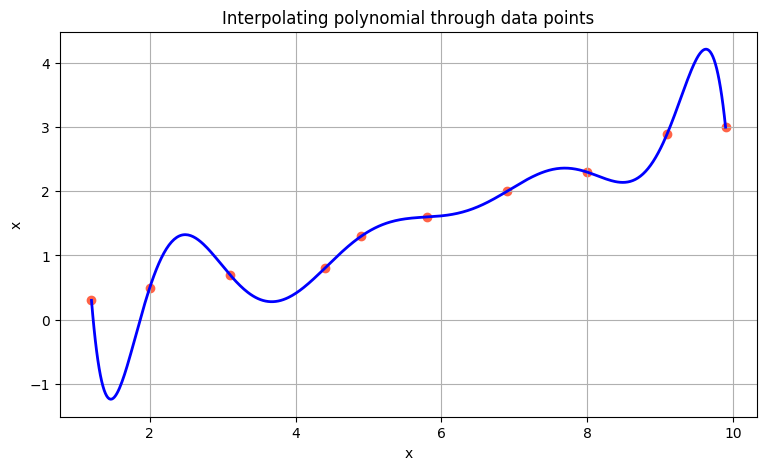

In [5]:
import numpy as np
from numpy import linalg as la
from matplotlib import pyplot as plt

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
n = len(x)

A = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        A[i, j]= x[i] ** (n -1 -j)

coeffs = la.solve(A, y)

xplt = np.linspace(x[0], x[-1], 500)
yplt = np.zeros_like(xplt)

for i, c in enumerate(coeffs):
    degree = n - 1 - i
    yplt += c*xplt**degree

#Plotting
plt.figure(figsize=(9, 5))
plt.plot(xplt, yplt, color='blue', linewidth=2, label='Interpolating polynomial')
plt.scatter(x, y, color='tomato', label='Data points')
plt.xlabel('x')
plt.ylabel('x')
plt.title('Interpolating polynomial through data points')
plt.legend
plt.grid()
plt.show

### Q7.6 (session quiz)

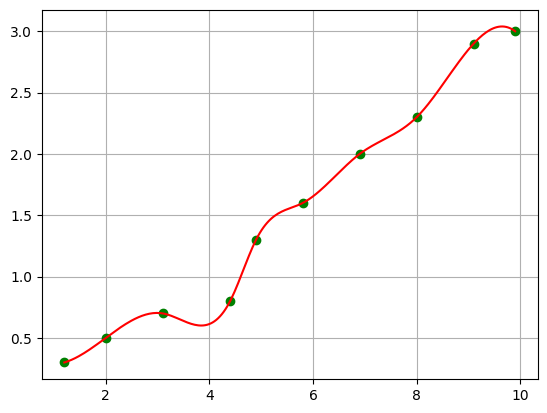

In [6]:
import numpy as np
from matplotlib.pyplot import figure, show
from scipy import interpolate as ip

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
f = ip.interp1d(x, y, kind='cubic')

newx = np.linspace(1.2,9.9,250) #Linspace limits must be the same as min and max in 'x'.
newy = f(newx)

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(x, y, 'go')
frame.plot(newx, newy, 'r')
frame.grid(True)
show()

This polynomial has significantly smaller oscillations then the polynomila from previous exercise.

In [32]:
class interpolation:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        
    def ip_linear(self):
        return ip.interp1d(self.x, self.y, kind='linear')
    
    def ip_polynomial(self, degree=None):
        if degree == None:
            degree = len(self.x)-1
        coeffs = np.polyfit(self.x, self.y, degree)
        return np.poly1d(coeffs)
    
    def ip_spline(self):
        return ip.interp1d(self.x, self.y, kind='cubic')
    
    def user_input(self, X, method, degree=None):
        if np.min(x) <= X <= np.max(x):
            if method == 'linear':
                func = self.ip_linear()
            elif method == 'polynomial':
                func = self.ip_polynomial(degree)
            elif method == 'spline':
                func = self.ip_spline()
            else:
                return "Error: method not recoginized."
            return func(X)
        else:
            return "X is not in range of x"

X = float(input('Input X: '))
method = input('Input a method: ')
inputval = interpolation(x, y)

result = inputval.user_input(X, method)
print(result)

Input X: 5
Input a method: polynomial
1.3731301577271893


### Q7.7 (session quiz)

### Q7.8 (coursework)

### Q7.9

### Q7.10 (session quiz)

### Q7.11 (coursework)

### Q7.12

### Q7.13 (coursework)

### Q7.14 (session quiz)